In [1]:
%load_ext autoreload
%autoreload 2
import sys

ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

Unexpected error: name 'os' is not defined


In [8]:
#HumanCT_res_df_GeneL = pd.read_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.June10.csv", index_col=0)
#HumanCT_res_df_GeneL.head(5)

In [5]:
ExpL = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.CT.Exp.Entrez.csv", index_col=0)
ExpL.columns = [int(x) for x in ExpL.columns.values ]

In [6]:
TPM = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/HumanCT.TPM.0.Filt.csv", index_col=0)
TPM.columns = [int(x) for x in TPM.columns.values ]

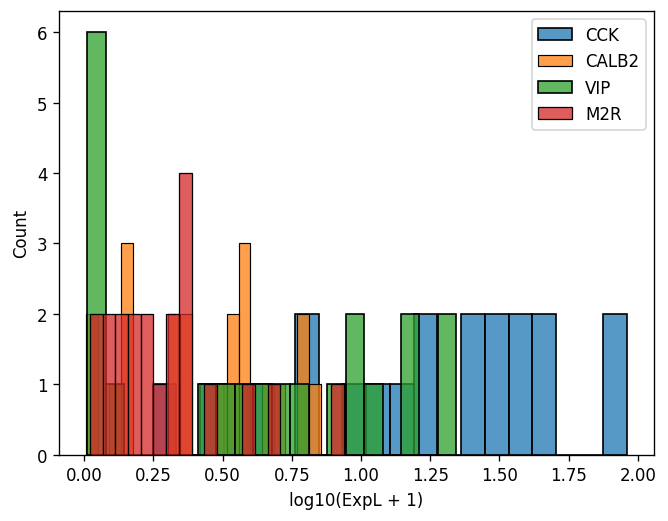

In [9]:
CGE_idx = Anno[Anno["Supercluster"]=="CGE interneuron"].index.values
CT = CGE_idx
PVALB_expl = ExpL.loc[GeneSymbol2Entrez["PVALB"], CT] 
CCK_expl = ExpL.loc[GeneSymbol2Entrez["CCK"], CT]
CALB2_expl = ExpL.loc[GeneSymbol2Entrez["CALB2"], CT]
SST_expl = ExpL.loc[GeneSymbol2Entrez["SST"], CT]
VIP_expl = ExpL.loc[GeneSymbol2Entrez["VIP"], CT]
SNCG_expl = ExpL.loc[GeneSymbol2Entrez["SNCG"], CT]
LAMP5_expl = ExpL.loc[GeneSymbol2Entrez["LAMP5"], CT]
LHX6_expl = ExpL.loc[GeneSymbol2Entrez["LHX6"], CT]
LAMP5_expl = ExpL.loc[GeneSymbol2Entrez["LAMP5"], CT]
M2R_expl = ExpL.loc[GeneSymbol2Entrez["CHRM2"], CT]     
plt.figure(dpi=120)
# sns.histplot(PVALB_expl, label="PVALB")
sns.histplot(np.log10(CCK_expl + 1), label="CCK", bins=20)
sns.histplot(np.log10(CALB2_expl + 1), label="CALB2", bins=20)
# sns.histplot(SST_expl, label="SST")
sns.histplot(np.log10(VIP_expl + 1), label="VIP", bins=20)
sns.histplot(np.log10(M2R_expl + 1), label="M2R", bins=20)
# sns.histplot(SNCG_expl, label="SNCG")

plt.xlabel("log10(ExpL + 1)")
plt.legend()

In [4]:
CGE_idx = Anno[Anno["Supercluster"]=="CGE interneuron"].index.values
CT = CGE_idx
PVALB_expl = TPM.loc[GeneSymbol2Entrez["PVALB"], CT] 
CCK_expl = TPM.loc[GeneSymbol2Entrez["CCK"], CT]
CALB2_expl = TPM.loc[GeneSymbol2Entrez["CALB2"], CT]
SST_expl = TPM.loc[GeneSymbol2Entrez["SST"], CT]
VIP_expl = TPM.loc[GeneSymbol2Entrez["VIP"], CT]
SNCG_expl = TPM.loc[GeneSymbol2Entrez["SNCG"], CT]
LAMP5_expl = TPM.loc[GeneSymbol2Entrez["LAMP5"], CT]
LHX6_expl = TPM.loc[GeneSymbol2Entrez["LHX6"], CT]
LAMP5_expl = TPM.loc[GeneSymbol2Entrez["LAMP5"], CT]
M2R_expl = TPM.loc[GeneSymbol2Entrez["CHRM2"], CT]     
plt.figure(dpi=120)
# sns.histplot(PVALB_expl, label="PVALB")
sns.histplot(CCK_expl, label="CCK", bins=20)
sns.histplot(CALB2_expl, label="CALB2", bins=20)
# sns.histplot(SST_expl, label="SST")
sns.histplot(VIP_expl, label="VIP", bins=20)
sns.histplot(M2R_expl, label="M2R", bins=20)
# sns.histplot(SNCG_expl, label="SNCG")

plt.xlabel("TPM")
plt.legend()

NameError: name 'TPM' is not defined

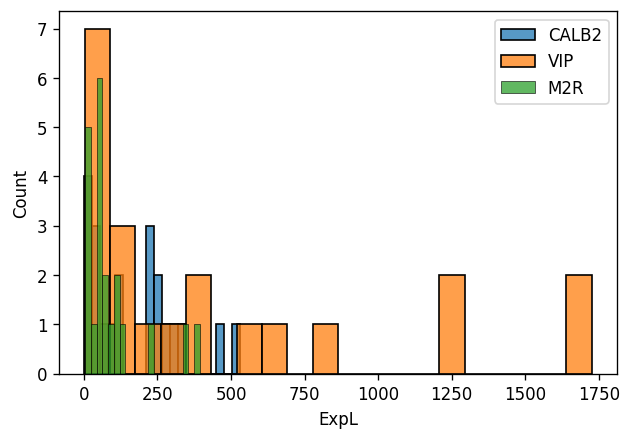

In [24]:
plt.figure(dpi=120)
# sns.histplot(PVALB_expl, label="PVALB")
# sns.histplot(CCK_expl, label="CCK", bins=20)
sns.histplot(CALB2_expl, label="CALB2", bins=20)
# sns.histplot(SST_expl, label="SST")
sns.histplot(VIP_expl, label="VIP", bins=20)
sns.histplot(M2R_expl, label="M2R", bins=20)
# sns.histplot(SNCG_expl, label="SNCG")

plt.xlabel("ExpL")
plt.legend()

In [25]:
#Bias_Save_Dict = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jun09/"
Bias_Save_Dir = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/dat/Spec_Bias_Jul07/"

SCZ_Bias = pd.read_csv(Bias_Save_Dir + "HCT.SCZ61.addP.csv", index_col=0)
HighIQ_ASD_Bias = pd.read_csv(Bias_Save_Dir + "HCT.ASD61.HIQ.addP.csv", index_col=0)
LowIQ_ASD_Bias = pd.read_csv(Bias_Save_Dir + "HCT.ASD61.LIQ.addP.csv", index_col=0)
X22q_Bias = pd.read_csv(Bias_Save_Dir + "HCT.X22q.addP.csv", index_col=0)
DDD_Bias = pd.read_csv(Bias_Save_Dir + "HCT.DDD.top61.addP.csv", index_col=0)

VNR_Pos_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_VNR_Pos_Bias_addP.csv", index_col=0)
VNR_Neg_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_VNR_Neg_Bias_addP.csv", index_col=0)
EDU_Pos_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_EDU_Pos_Bias_addP.csv", index_col=0)
EDU_Neg_Bias = pd.read_csv(Bias_Save_Dir + "UKBB_EDU_Neg_Bias_addP.csv", index_col=0)

#VNR_Pos_Bias = pd.read_csv(os.path.join(Bias_Save_Dict, "CTBias.VNR.Pos.top61.csv"), index_col=0)
#VNR_Neg_Bias = pd.read_csv(os.path.join(Bias_Save_Dict, "CTBias.VNR.Neg.top61.csv"), index_col=0)

In [26]:
BiasDFs = [X22q_Bias, HighIQ_ASD_Bias, LowIQ_ASD_Bias, VNR_Pos_Bias, VNR_Neg_Bias, DDD_Bias, SCZ_Bias]
BiasDF_Names = ["X22q", "HighIQ_ASD", "LowIQ_ASD", "VNR_Pos", "VNR_Neg", "DDD", "SCZ"]
for i, row in X22q_Bias.iterrows():
    for BiasDF, name in zip(BiasDFs, BiasDF_Names):
        X22q_Bias.loc[i, name+"_Bias"] = BiasDF.loc[i, "EFFECT"]

In [27]:
TmpDF = X22q_Bias[["Class","Supercluster","X22q_Bias", "HighIQ_ASD_Bias", "LowIQ_ASD_Bias", "VNR_Pos_Bias", "VNR_Neg_Bias", "DDD_Bias", "SCZ_Bias"]]

In [28]:
Biases_CGE = TmpDF[TmpDF["Supercluster"]=="CGE interneuron"]
for i, row in Biases_CGE.iterrows():
    Biases_CGE.loc[i, "VIP_ExpL"] = ExpL.loc[GeneSymbol2Entrez["VIP"], i]
    Biases_CGE.loc[i, "CCK_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CCK"], i]
    Biases_CGE.loc[i, "CR_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CALB2"], i]
    Biases_CGE.loc[i, "M2R_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CHRM2"], i]

/tmp/ipykernel_561643/1555056789.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Biases_CGE.loc[i, "VIP_ExpL"] = ExpL.loc[GeneSymbol2Entrez["VIP"], i]
/tmp/ipykernel_561643/1555056789.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Biases_CGE.loc[i, "CCK_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CCK"], i]
/tmp/ipykernel_561643/1555056789.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [29]:
Biases_CGE

,Class,Supercluster,X22q_Bias,HighIQ_ASD_Bias,LowIQ_ASD_Bias,VNR_Pos_Bias,VNR_Neg_Bias,DDD_Bias,SCZ_Bias,VIP_ExpL,CCK_ExpL,CR_ExpL,M2R_ExpL
293,NEUR,CGE interneuron,0.171896,0.020035,0.151296,-0.017644,0.072862,0.193049,0.073083,13.958615,23.516962,2.593066,0.483934
295,NEUR,CGE interneuron,0.170202,-0.001746,0.142621,-0.026179,0.109062,0.186642,0.119488,18.733238,43.597927,5.052621,0.123730
294,NEUR,CGE interneuron,0.149910,0.025150,0.175922,-0.037422,0.058421,0.198343,0.102939,21.116175,27.631880,2.815268,0.267935
280,NEUR,CGE interneuron,0.149726,0.117004,0.181741,-0.049349,0.016876,0.222487,0.191434,1.858206,78.125930,1.327654,0.387975
279,NEUR,CGE interneuron,0.149702,0.126929,0.205152,-0.057055,0.079258,0.188649,0.200730,2.963595,90.443985,1.023106,1.815153
281,NEUR,CGE interneuron,0.149497,0.130123,0.177562,-0.018698,0.094774,0.168708,0.226198,4.373322,33.676365,2.556849,0.360788
296,NEUR,CGE interneuron,0.140227,0.036358,0.197997,-0.098806,0.105025,0.247004,0.153340,13.942251,14.610457,1.374632,0.481940
291,NEUR,CGE interneuron,0.132346,0.017447,0.085168,-0.090971,0.064239,0.119617,0.118558,2.343056,3.050735,3.933824,1.167892
288,NEUR,CGE interneuron,0.125923,0.057968,0.138364,-0.159986,0.043453,0.275430,0.170756,0.044702,15.614676,0.016069,0.652853
284,NEUR,CGE interneuron,0.121431,0.098188,0.212908,-0.096048,0.079416,0.232545,0.185662,5.386541,0.769239,3.823691,1.099023


In [30]:
VIP_Pos = Biases_CGE[Biases_CGE["VIP_ExpL"] > 1]
VIP_Neg = Biases_CGE[Biases_CGE["VIP_ExpL"] < 1]
CCK_Cutoff = 30
CR_Cutoff = 2
M2R_Cutoff = 2
CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

2 2 6 4


In [31]:
def plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias"):
    plt.figure(figsize=(8,6))

    # Create boxplot
    bp = plt.boxplot([CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label]],
                     tick_labels=['CCKBC', 'ISI2', 'ISI3', 'Other', 'VIP-'])

    # Add individual points with jitter
    for i, data in enumerate([CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label]], 1):
        x = np.random.normal(i, 0.04, size=len(data))
        plt.plot(x, data, 'o', alpha=0.5, color='black', markersize=4)

    plt.ylabel(label)
    plt.title(label)

    # Perform Kruskal-Wallis H-test
    h_stat, p_val = stats.kruskal(CCKBC[label], ISI2[label], ISI3[label], Other[label], VIP_Neg[label])
    plt.text(0.02, 0.98, f'Kruskal-Wallis p={p_val:.2e}', 
             transform=plt.gca().transAxes, verticalalignment='top')

    plt.show()


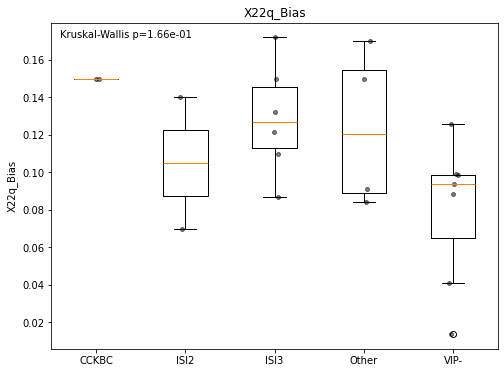

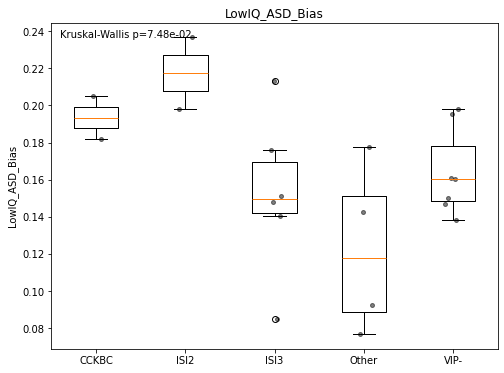

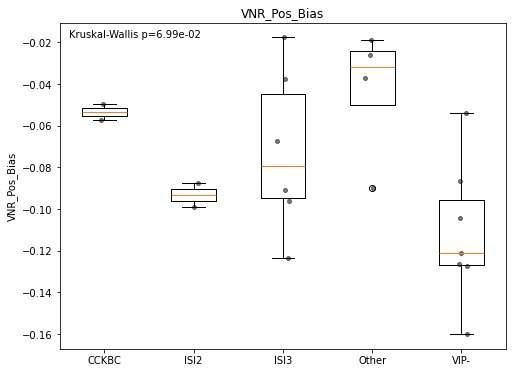

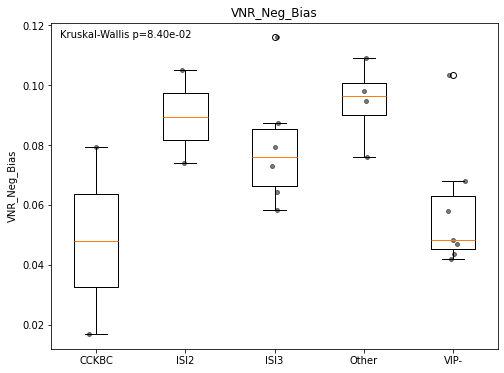

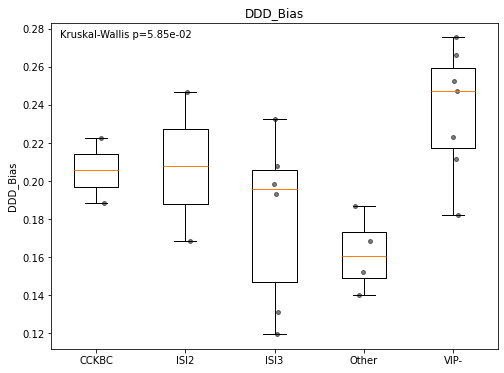

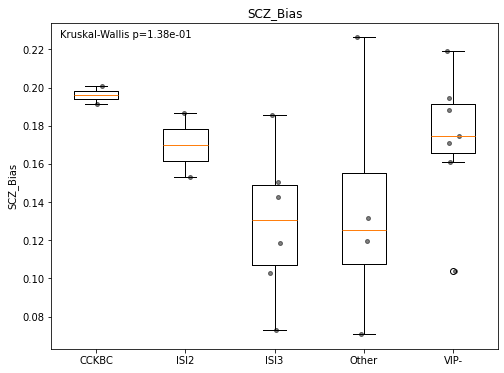

In [32]:
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="X22q_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="LowIQ_ASD_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Pos_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="VNR_Neg_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="DDD_Bias")
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="SCZ_Bias")

In [33]:
PBS_CGE = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"]
for i, row in PBS_CGE.iterrows():
    PBS_CGE.loc[i, "VIP_ExpL"] = ExpL.loc[GeneSymbol2Entrez["VIP"], i]
    PBS_CGE.loc[i, "CCK_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CCK"], i]
    PBS_CGE.loc[i, "CR_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CALB2"], i]
    PBS_CGE.loc[i, "M2R_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CHRM2"], i]
PBS_CGE.head(5)

/tmp/ipykernel_561643/2332323738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PBS_CGE.loc[i, "VIP_ExpL"] = ExpL.loc[GeneSymbol2Entrez["VIP"], i]
/tmp/ipykernel_561643/2332323738.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  PBS_CGE.loc[i, "CCK_ExpL"] = ExpL.loc[GeneSymbol2Entrez["CCK"], i]
/tmp/ipykernel_561643/2332323738.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,...,std_err,p_rho_perm,p_beta_perm,p_beta_perm_Log,p_rho_perm_FDR,p_beta_perm_FDR,VIP_ExpL,CCK_ExpL,CR_ExpL,M2R_ExpL
276,276,CGE interneuron,-0.449393,0.000512,-0.426037,0.001061,-18.083663,-28.560677,-7.606648,66.188998,...,5.225758,0.0001,0.0001,4.000000,0.015367,0.015367,8.779327,24.634615,0.432692,1.314423
295,295,CGE interneuron,-0.396281,0.002499,-0.413430,0.001540,-18.364459,-29.399269,-7.329649,64.478525,...,5.503977,0.0008,0.0002,3.698970,0.046100,0.015367,18.733238,43.597927,5.052621,0.123730
294,294,CGE interneuron,-0.404252,0.002002,-0.420899,0.001237,-18.232253,-28.952707,-7.511800,64.920332,...,5.347181,0.0006,0.0002,3.698970,0.046100,0.015367,21.116175,27.631880,2.815268,0.267935
279,279,CGE interneuron,-0.320321,0.016093,-0.406134,0.001898,-17.808293,-28.740353,-6.876233,66.043945,...,5.452727,0.0064,0.0002,3.698970,0.142690,0.015367,2.963595,90.443985,1.023106,1.815153
296,296,CGE interneuron,-0.324526,0.014679,-0.372609,0.004683,-15.816929,-26.564324,-5.069533,64.606159,...,5.360620,0.0054,0.0007,3.154902,0.131021,0.023050,13.942251,14.610457,1.374632,0.481940


In [34]:
VIP_Pos = PBS_CGE[PBS_CGE["VIP_ExpL"] > 1]
VIP_Neg = PBS_CGE[PBS_CGE["VIP_ExpL"] < 1]
CCK_Cutoff = 50
CR_Cutoff = 2
M2R_Cutoff = 2
CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

2 2 9 1


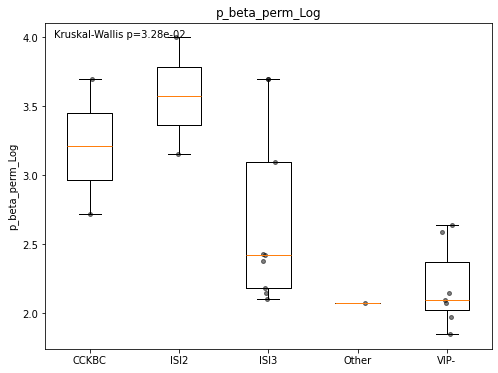

In [35]:
plot_beta_distribution(CCKBC, ISI2, ISI3, Other, VIP_Neg, label="p_beta_perm_Log")

In [42]:
Biases_CGE = TmpDF[TmpDF["Supercluster"]=="CGE interneuron"]
for i, row in Biases_CGE.iterrows():
    Biases_CGE.loc[i, "VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], i]
    Biases_CGE.loc[i, "CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], i]
    Biases_CGE.loc[i, "CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], i]
    Biases_CGE.loc[i, "CR_ExpL"] = TPM.loc[GeneSymbol2Entrez["CALB2"], i]
    Biases_CGE.loc[i, "M2R_ExpL"] = TPM.loc[GeneSymbol2Entrez["CHRM2"], i]

/tmp/ipykernel_561643/351215424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Biases_CGE.loc[i, "VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], i]
/tmp/ipykernel_561643/351215424.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Biases_CGE.loc[i, "CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], i]
/tmp/ipykernel_561643/351215424.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [43]:
Biases_CGE

,Class,Supercluster,X22q_Bias,HighIQ_ASD_Bias,LowIQ_ASD_Bias,VNR_Pos_Bias,VNR_Neg_Bias,DDD_Bias,SCZ_Bias,VIP_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
293,NEUR,CGE interneuron,0.171896,0.020035,0.151296,-0.017644,0.072862,0.193049,0.073083,1273.162043,2144.976661,390.200315,236.512950,44.139466
295,NEUR,CGE interneuron,0.170202,-0.001746,0.142621,-0.026179,0.109062,0.186642,0.119488,1725.548746,4015.875327,1725.848109,465.405064,11.396987
294,NEUR,CGE interneuron,0.149910,0.025150,0.175922,-0.037422,0.058421,0.198343,0.102939,1659.097026,2171.035708,1028.786178,221.195494,21.051680
280,NEUR,CGE interneuron,0.149726,0.117004,0.181741,-0.049349,0.016876,0.222487,0.191434,140.480972,5906.345447,2889.098805,100.371054,29.331029
279,NEUR,CGE interneuron,0.149702,0.126929,0.205152,-0.057055,0.079258,0.188649,0.200730,132.596978,4046.639007,5543.738644,45.775739,81.213464
281,NEUR,CGE interneuron,0.149497,0.130123,0.177562,-0.018698,0.094774,0.168708,0.226198,227.445121,1751.420494,3185.628401,132.975082,18.763641
296,NEUR,CGE interneuron,0.140227,0.036358,0.197997,-0.098806,0.105025,0.247004,0.153340,1276.558558,1337.739789,1126.393311,125.861949,44.126669
291,NEUR,CGE interneuron,0.132346,0.017447,0.085168,-0.090971,0.064239,0.119617,0.118558,156.030757,203.157170,442.499739,261.964548,77.773270
288,NEUR,CGE interneuron,0.125923,0.057968,0.138364,-0.159986,0.043453,0.275430,0.170756,3.590300,1254.107929,126.902538,1.290567,52.434551
284,NEUR,CGE interneuron,0.121431,0.098188,0.212908,-0.096048,0.079416,0.232545,0.185662,432.365212,61.745055,281.531728,306.918850,88.216039


In [45]:
# 
VIP_Pos = Biases_CGE[Biases_CGE["VIP_ExpL"] > 100]
VIP_Neg = Biases_CGE[Biases_CGE["VIP_ExpL"] < 100]
CCK_Cutoff = 2000
CR_Cutoff = 100
M2R_Cutoff = 100
CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

1 1 5 7


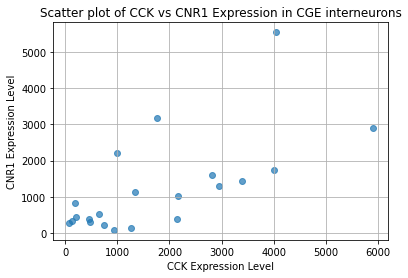

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(Biases_CGE["CCK_ExpL"], Biases_CGE["CNR1_ExpL"], alpha=0.7)
plt.xlabel("CCK Expression Level")
plt.ylabel("CNR1 Expression Level")
plt.title("Scatter plot of CCK vs CNR1 Expression in CGE interneurons")
plt.grid(True)
plt.show()

In [47]:
test = Biases_CGE[["VIP_ExpL", "CCK_ExpL", "CNR1_ExpL", "CR_ExpL", "M2R_ExpL"]]

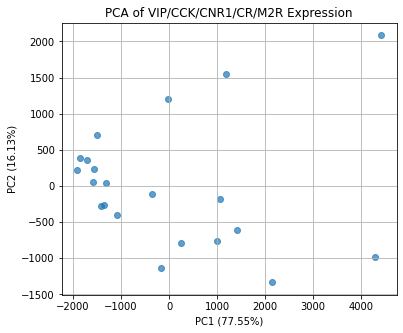

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(test.fillna(0))  # Fill NaNs with 0 for PCA

# Plot the first two principal components
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('PC1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of VIP/CCK/CNR1/CR/M2R Expression')
plt.grid(True)
plt.show()

In [54]:
test

,VIP_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
293,1273.162043,2144.976661,390.200315,236.512950,44.139466
295,1725.548746,4015.875327,1725.848109,465.405064,11.396987
294,1659.097026,2171.035708,1028.786178,221.195494,21.051680
280,140.480972,5906.345447,2889.098805,100.371054,29.331029
279,132.596978,4046.639007,5543.738644,45.775739,81.213464
281,227.445121,1751.420494,3185.628401,132.975082,18.763641
296,1276.558558,1337.739789,1126.393311,125.861949,44.126669
291,156.030757,203.157170,442.499739,261.964548,77.773270
288,3.590300,1254.107929,126.902538,1.290567,52.434551
284,432.365212,61.745055,281.531728,306.918850,88.216039


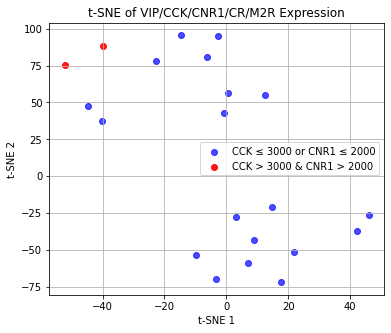

In [61]:
from sklearn.manifold import TSNE

# t-SNE on test (fill NaNs with 0)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(test.fillna(0))

def plot_tsne_mask(X_tsne, mask, mask_label='Masked', unmask_label='Unmasked', 
                   mask_color='red', unmask_color='blue', title='t-SNE of VIP/CCK/CNR1/CR/M2R Expression'):
    """
    Plots t-SNE results with a boolean mask to highlight points.

    Parameters:
    - X_tsne: np.ndarray, shape (n_samples, 2)
    - mask: boolean array, shape (n_samples,)
    - mask_label: label for masked points
    - unmask_label: label for unmasked points
    - mask_color: color for masked points
    - unmask_color: color for unmasked points
    - title: plot title
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 5))
    plt.scatter(X_tsne[~mask, 0], X_tsne[~mask, 1], alpha=0.7, color=unmask_color, label=unmask_label)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.9, color=mask_color, label=mask_label)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
# Highlight points with CCK_ExpL > 3000 and CNR1_ExpL > 2000
mask = (test["CCK_ExpL"] > 3000) & (test["CNR1_ExpL"] > 2000 & (test["VIP_ExpL"] > 100))
plot_tsne_mask(
    X_tsne, 
    mask, 
    mask_label='CCK > 3000 & CNR1 > 2000', 
    unmask_label='CCK ≤ 3000 or CNR1 ≤ 2000'
)


In [67]:
from sklearn.manifold import TSNE

# t-SNE on test (fill NaNs with 0)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(test.fillna(0))

def plot_tsne_multi_mask(X_tsne, masks, labels=None, colors=None, title='t-SNE of VIP/CCK/CNR1/CR/M2R Expression'):
    """
    Plots t-SNE results with multiple boolean masks to highlight groups of points.

    Parameters:
    - X_tsne: np.ndarray, shape (n_samples, 2)
    - masks: list of boolean arrays, each shape (n_samples,)
    - labels: list of str, label for each mask
    - colors: list of str, color for each mask
    - title: plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np

    n = len(masks)
    if labels is None:
        labels = [f"Mask {i+1}" for i in range(n)]
    if colors is None:
        # Use some default matplotlib colors
        default_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
        colors = default_colors[:n]

    plt.figure(figsize=(6, 5), dpi=120)
    already_masked = np.zeros(X_tsne.shape[0], dtype=bool)
    for mask, label, color in zip(masks, labels, colors):
        # Only plot points not already assigned to a previous mask
        mask_to_plot = mask & (~already_masked)
        plt.scatter(X_tsne[mask_to_plot, 0], X_tsne[mask_to_plot, 1], alpha=0.8, color=color, label=label)
        already_masked = already_masked | mask
    # Optionally plot the rest as "Other"
    if not np.all(already_masked):
        plt.scatter(X_tsne[~already_masked, 0], X_tsne[~already_masked, 1], alpha=0.3, color='lightgray', label='Other')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True)
    plt.show()



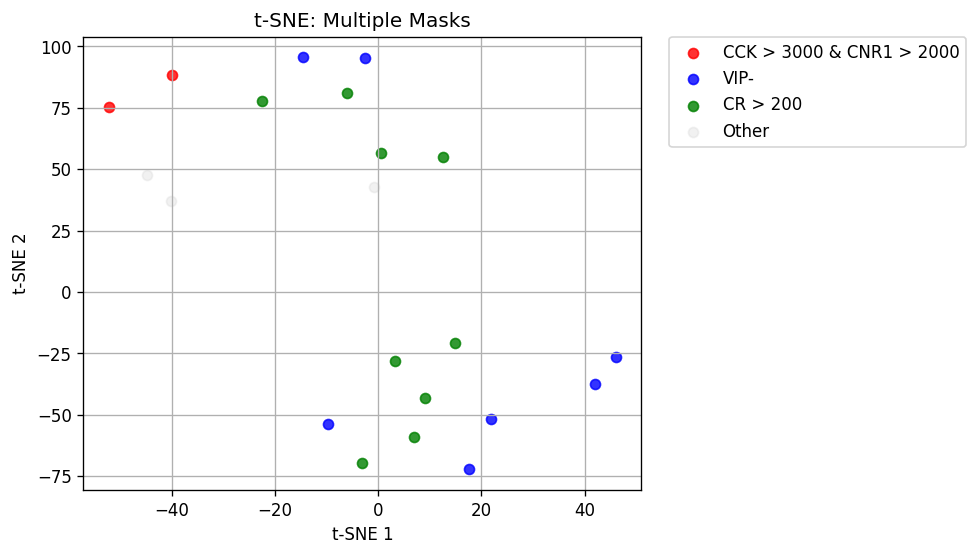

In [69]:

# Example usage:
# Define multiple masks
mask1 = (test["CCK_ExpL"] > 3000) & (test["CNR1_ExpL"] > 2000)
mask2 = (test["VIP_ExpL"] < 100)
mask3 = (test["CR_ExpL"] > 200)
masks = [mask1, mask2, mask3]
labels = ['CCK > 3000 & CNR1 > 2000', 'VIP-', 'CR > 200']
colors = ['red', 'blue', 'green']

plot_tsne_multi_mask(
    X_tsne,
    masks,
    labels=labels,
    colors=colors,
    title='t-SNE: Multiple Masks'
)

In [109]:
PBS_CGE = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"].copy()
PBS_CGE["VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], PBS_CGE.index]
PBS_CGE["SST_ExpL"] = TPM.loc[GeneSymbol2Entrez["SST"], PBS_CGE.index]
PBS_CGE["PVALB_ExpL"] = TPM.loc[GeneSymbol2Entrez["PVALB"], PBS_CGE.index]
PBS_CGE["NPY_ExpL"] = TPM.loc[GeneSymbol2Entrez["NPY"], PBS_CGE.index]
PBS_CGE["CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], PBS_CGE.index]
PBS_CGE["CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], PBS_CGE.index]
PBS_CGE["CR_ExpL"] = TPM.loc[GeneSymbol2Entrez["CALB2"], PBS_CGE.index]
PBS_CGE["M2R_ExpL"] = TPM.loc[GeneSymbol2Entrez["CHRM2"], PBS_CGE.index]

PBS_OtherIN = HumanCT_res_df_GeneL[
    (HumanCT_res_df_GeneL["Supercluster"] == "MGE interneuron") | 
    (HumanCT_res_df_GeneL["Supercluster"] == "LAMP5-LHX6 and Chandelier")
].copy()
PBS_OtherIN["VIP_ExpL"] = TPM.loc[GeneSymbol2Entrez["VIP"], PBS_OtherIN.index]
PBS_OtherIN["SST_ExpL"] = TPM.loc[GeneSymbol2Entrez["SST"], PBS_OtherIN.index]
PBS_OtherIN["PVALB_ExpL"] = TPM.loc[GeneSymbol2Entrez["PVALB"], PBS_OtherIN.index]
PBS_OtherIN["NPY_ExpL"] = TPM.loc[GeneSymbol2Entrez["NPY"], PBS_OtherIN.index]
PBS_OtherIN["CCK_ExpL"] = TPM.loc[GeneSymbol2Entrez["CCK"], PBS_OtherIN.index]
PBS_OtherIN["CNR1_ExpL"] = TPM.loc[GeneSymbol2Entrez["CNR1"], PBS_OtherIN.index]
PBS_OtherIN["CR_ExpL"] = TPM.loc[GeneSymbol2Entrez["CALB2"], PBS_OtherIN.index]
PBS_OtherIN["M2R_ExpL"] = TPM.loc[GeneSymbol2Entrez["CHRM2"], PBS_OtherIN.index]


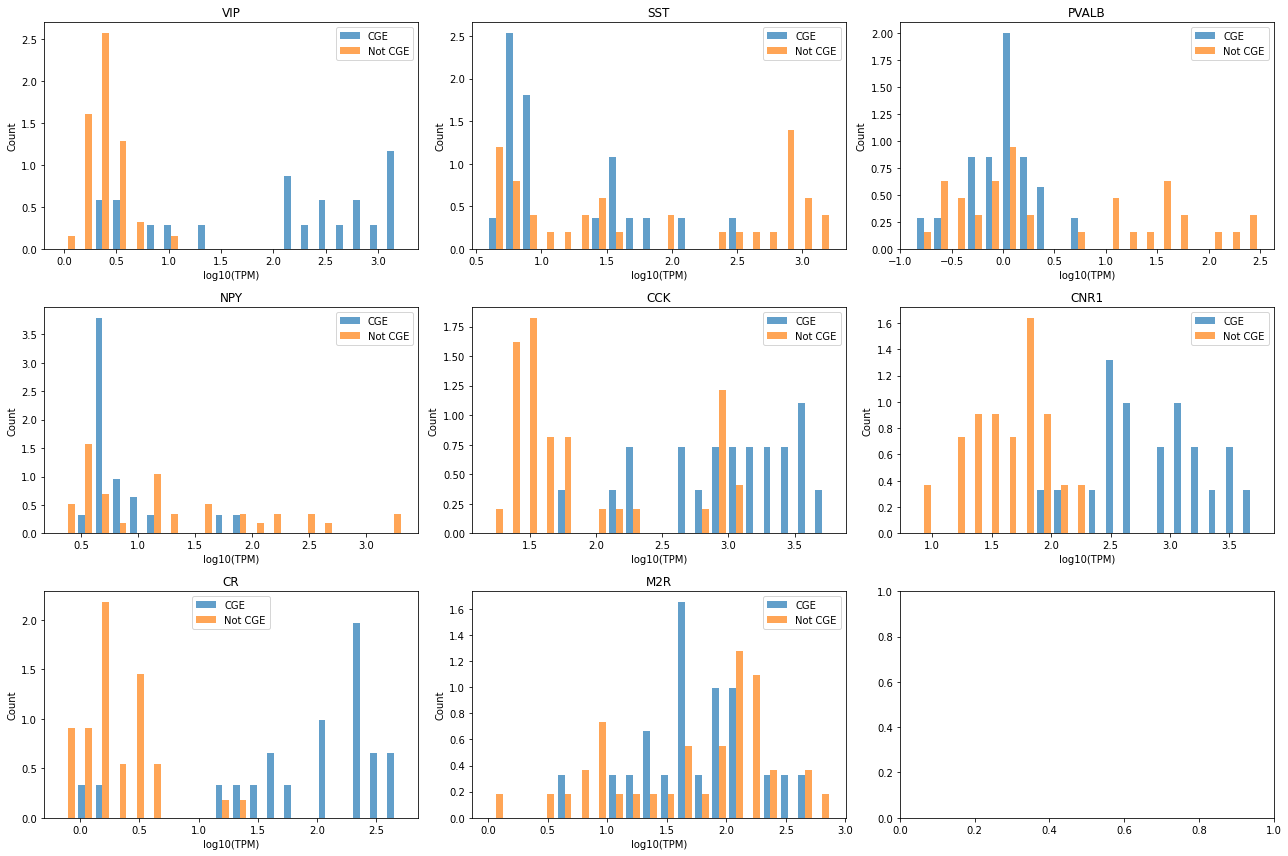

In [113]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
genes = ["VIP_ExpL", "SST_ExpL", "PVALB_ExpL", "NPY_ExpL", "CCK_ExpL", "CNR1_ExpL", "CR_ExpL", "M2R_ExpL"]
titles = ["VIP", "SST", "PVALB", "NPY", "CCK", "CNR1", "CR", "M2R"]

for ax, gene, title in zip(axes.flat, genes, titles):
    ax.hist(
        [np.log10(PBS_CGE[gene]), np.log10(PBS_OtherIN[gene])],
        label=["CGE", "Not CGE"],
        alpha=0.7,
        bins=20,
        density=True
    )
    ax.set_title(title)
    ax.set_xlabel('log10(TPM)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [95]:
VIP_Cutoff = 100
CCK_Cutoff = 3000
CR_Cutoff = 100
M2R_Cutoff = 100

VIP_Pos = PBS_CGE[PBS_CGE["VIP_ExpL"] > VIP_Cutoff]
VIP_Neg = PBS_CGE[PBS_CGE["VIP_ExpL"] < VIP_Cutoff]

CCKBC = VIP_Pos[(VIP_Pos["CCK_ExpL"] > CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI2 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] < CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]
ISI3 = VIP_Pos[(VIP_Pos["CCK_ExpL"] < CCK_Cutoff) & (VIP_Pos["CR_ExpL"] > CR_Cutoff) & (VIP_Pos["M2R_ExpL"] < M2R_Cutoff)]

# Fix: Concatenate index values using np.concatenate instead of + operator
combined_indices = np.concatenate([CCKBC.index.values, ISI2.index.values, ISI3.index.values])
Other = VIP_Pos.loc[~VIP_Pos.index.isin(combined_indices)]

print(len(CCKBC), len(ISI2), len(ISI3), len(Other))

1 1 7 5


In [118]:
PBS_CGE[PBS_CGE["CCK_ExpL"] > 5000]

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,...,p_rho_perm_FDR,p_beta_perm_FDR,VIP_ExpL,SST_ExpL,PVALB_ExpL,NPY_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
280,280,CGE interneuron,-0.255926,0.056934,-0.353467,0.007533,-15.810068,-27.225595,-4.394541,65.56825,...,0.242574,0.043795,140.480972,6.144562,1.154882,5.522703,5906.345447,2889.098805,100.371054,29.331029


In [114]:
PBS_CGE[PBS_CGE["p_beta_perm_FDR"]>0.05]

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,...,p_rho_perm_FDR,p_beta_perm_FDR,VIP_ExpL,SST_ExpL,PVALB_ExpL,NPY_ExpL,CCK_ExpL,CNR1_ExpL,CR_ExpL,M2R_ExpL
289,289,CGE interneuron,-0.203715,0.132087,-0.323667,0.014959,-15.203871,-27.329854,-3.077887,64.179504,...,0.373190,0.064736,316.724856,6.227508,2.384285,5.383215,467.042852,311.111976,217.591302,117.626962
291,291,CGE interneuron,-0.206313,0.127122,-0.323655,0.014963,-14.513066,-26.088579,-2.937553,63.702465,...,0.369911,0.065462,156.030757,4.858449,1.028272,6.142429,203.157170,442.499739,261.964548,77.773270
277,277,CGE interneuron,-0.369518,0.005066,-0.318362,0.016791,-14.105240,-25.564181,-2.646299,65.260161,...,0.086438,0.065462,2.331941,8.332804,0.279833,3.357995,127.417281,340.712181,54.318685,393.538429
285,285,CGE interneuron,-0.279420,0.037018,-0.312624,0.018985,-13.743238,-25.135920,-2.350555,64.320598,...,0.205581,0.066845,560.224969,24.909144,0.725253,14.043535,637.088576,523.105158,338.284360,51.967674
287,287,CGE interneuron,-0.245992,0.067623,-0.303412,0.023015,-14.583292,-27.078498,-2.088086,64.722478,...,0.293996,0.066845,2.027901,47.242590,2.361712,4.957093,934.749859,84.779631,1.322726,20.967498
290,290,CGE interneuron,-0.178627,0.187773,-0.315724,0.017771,-13.850031,-25.206227,-2.493834,63.556657,...,0.432442,0.066845,630.893903,6.648101,1.328713,4.838693,745.829871,216.244674,270.776333,342.749052
288,288,CGE interneuron,-0.250162,0.062955,-0.312799,0.018914,-13.920546,-25.453030,-2.388062,64.354683,...,0.293996,0.066845,3.590300,6.168200,1.452292,4.395692,1254.107929,126.902538,1.290567,52.434551
282,282,CGE interneuron,-0.192590,0.155010,-0.291162,0.029471,-12.268879,-23.267168,-1.270589,64.566969,...,0.386087,0.078297,19.160384,42.692030,6.364329,5.613318,2823.374109,1590.523834,47.111438,138.609489
283,283,CGE interneuron,-0.204365,0.130832,-0.293213,0.028296,-12.842823,-24.267626,-1.418020,64.682476,...,0.369911,0.088462,11.745396,109.905234,0.994180,5.498781,190.187434,827.570901,263.712741,57.759197


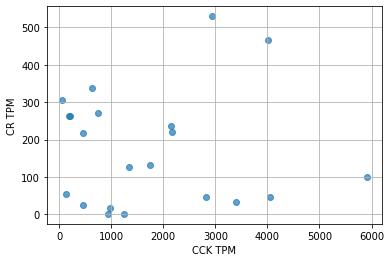

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
Marker1 = "CCK"
Marker2 = "CR"
plt.scatter(PBS_CGE[f"{Marker1}_ExpL"], PBS_CGE[f"{Marker2}_ExpL"], alpha=0.7)
plt.xlabel(f"{Marker1} TPM")
plt.ylabel(f"{Marker2} TPM")
plt.grid(True)
plt.show()